<ggplot: (640 x 480)>


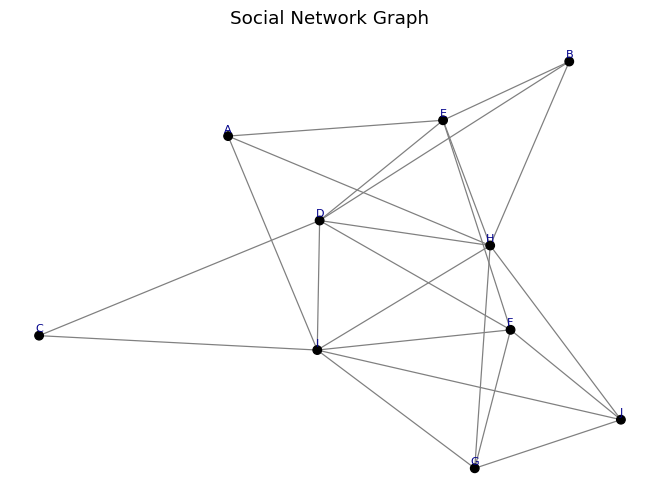

In [9]:
import networkx as nx
import pandas as pd
from plotnine import *
import matplotlib.pyplot as plt


# Create an undirected graph with 10 nodes
G = nx.gnp_random_graph(10, 0.5)

# Assign labels
labels = {i: chr(65 + i) for i in G.nodes()}
nx.set_node_attributes(G, labels, 'label')


# Extract node positions using spring layout
pos = nx.spring_layout(G, seed=42)

# Create node DataFrame
nodes_df = pd.DataFrame({
    'x': [pos[n][0] for n in G.nodes()],
    'y': [pos[n][1] for n in G.nodes()],
    'name': [G.nodes[n]['label'] for n in G.nodes()]
})

# Create edge DataFrame
edges_df = pd.DataFrame([
    {'x': pos[u][0], 'y': pos[u][1], 'xend': pos[v][0], 'yend': pos[v][1]}
    for u, v in G.edges()
])


network_plot = (
    ggplot() +
    geom_segment(data=edges_df, mapping=aes(x='x', y='y', xend='xend', yend='yend'),
                 color="gray", size=0.5) +
    geom_point(data=nodes_df, mapping=aes(x='x', y='y'), color='black', size=3) +
    geom_text(data=nodes_df, mapping=aes(x='x', y='y', label='name'),
              nudge_y=0.03, size=8, color='darkblue') +
    theme_void() +
    ggtitle("Social Network Graph")
)

print(network_plot)
network_plot.draw()